# Laser Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

In [ ]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

# Set Instruments Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)
params.MSO5_set_standard_counts(MS)
p_att.write(f'VOLT {params.device_line_1['v_attenuator_vals']['att_blue_v']}')
# yoko.current(0)
# Check shielding: box and fridge entry 

# Import

In [2]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-05-11_SNSPD11.db")
import snspd
params = snspd.snspd('snspd11.yaml')

# Set up experiment
exp_name = 'SNSPD11_11_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260519-36716-qcodes.log
Experiment loaded. Last ID no: 225


In [3]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd11.yaml')

# Instruments

In [8]:
# station = Station(config_file="friesland.yaml")
# dmm = station.load_instrument("dmm", revive_instance=True)
# yoko = station.load_instrument("yoko", revive_instance=True)
# laser = station.load_instrument("laser", revive_instance=True)
# MS = station.load_instrument("osc", revive_instance=True)
pm100d = station.load_instrument("pm100d", revive_instance=True) 
pms120 = station.load_instrument("pms120", revive_instance=True)
tc = station.load_instrument("fridge", revive_instance=True)
p_att = station.load_instrument("dmm_keithley", revive_instance=True) # excluding from snapshot because none of the parameters work anyway

Connected to: Thorlabs PM100D (serial:P0033329, firmware:2.8.1) in 5.54s


2026-05-19 11:30:04,141 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-05-19 11:30:04,282 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Connected to: Keithley instruments 2230G-30-1 (serial:9010428, firmware:1.16-1.04) in 0.15s


In [9]:
params.initialize_station()

# Light Counts vs Current (multiple wavelengths)
Counts vs current function now saves wavelength and attenuation. Choose 5V for variable attenuator 

In [11]:
params.laser_wav_range.values()

dict_values(['1528e-9', '1565e-9', '1e-9'])

In [10]:
l = [float(val) for val in params.laser_wav_range.values()]
laser_wav_range = np.arange(l[0], l[1]+l[2], l[2])

{'start': 3.4, 'stop': 5.55, 'step': 0.05}

In [17]:
yoko.current(0)

In [20]:
wavelength_range = [1540e-9, 1550e-9, 1560e-9]

for wav in wavelength_range: 
    
    ############################ TURN LASER OFF ############################ 
    laser.enable(False)
    print(f'Laser enable status: {laser.enable()}')
    
    params.laser_set_standard(laser, wavelength=wav, power=7)
    params.laser_get_standard(laser)
    params.pmeter_set_standard(pmeter=pm100d, wavelength=wav)
    params.pmeter_set_standard(pmeter=pms120, wavelength=wav)
    params.MSO5_set_standard_counts(MS)
    p_att.write(f'VOLT 5')
    # yoko.current(0)
    # Check shielding: box and fridge entry 
    time.sleep(10)
    
    ############################ TURN LASER ON ############################ 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(30) # <- increase to 30s wait time when wavelength is being swept 
    
    params.MSO5_counts_vs_current(device=params.device_line_1, n_captures=10, interval=1, osc=MS, dmm=dmm, yoko=yoko, pmeter90=pms120) 
    
    ############################ TURN LASER OFF ############################ 
    laser.enable(False)
    print(f'Laser enable status: {laser.enable()}')

2026-05-19 11:45:47,910 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
Power: 7.0
Frequency coarse: 194.6704THz
Wavelength (calculated) is 1540.000215749287nm
Powermeter wavelength is 1.54e-06
Powermeter wavelength is 1.54e-06
Laser enable status: True
Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 226. 
226
This acquisition will take 10s
11 46


2026-05-19 11:46:48,117 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



This acquisition will take 10s
11 46


2026-05-19 11:47:03,327 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



...

This acquisition will take 10s
12 6


2026-05-19 12:07:01,813 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



This acquisition will take 10s
12 7


2026-05-19 12:07:16,974 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()

2026-05-19 12:07:22,014 ¦ qcodes.dataset.measurements ¦ WARNING ¦ measurements ¦ __exit__ ¦ 758 ¦ An exception occurred in measurement with guid: 5d43a116-0000-0000-0000-019e3df8930b;
Traceback:
Traceback (most recent call last):
  File "D:\SNSPD\SNSPD2\snspd.py", line 418, in MSO5_counts_vs_current
    time.sleep(5)
    ~~~~~~~~~~^^^
KeyboardInterrupt



KeyboardInterrupt: 

Aborted during 1550nm sweep, taking too long for right now. 

# OLD

In [6]:
station = Station(config_file="friesland.yaml")
dmm = station.load_instrument("dmm", revive_instance=True)
yoko = station.load_instrument("yoko", revive_instance=True)
laser = station.load_instrument("laser", revive_instance=True)
MS = station.load_instrument("osc", revive_instance=True)
pm100d = station.load_instrument("pm100d", revive_instance=True) 
pms120 = station.load_instrument("pms120", revive_instance=True)
tc = station.load_instrument("fridge", revive_instance=True)
p_att = station.load_instrument("dmm_keithley", revive_instance=True) # excluding from snapshot because none of the parameters work anyway

Connected to: Thorlabs PM100D (serial:P0033329, firmware:2.8.1) in 5.54s


2026-05-18 13:22:31,133 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter


In [8]:
params.device_line_1_name

'R9C9'

Negative voltages for this device due to polarity of four wire connection

In [13]:
params.critical_current(dmm=dmm, yoko=yoko, tc=tc, currents=np.arange(0,-15.25e-6, -0.25e-6), device_name=params.device_line_1_name, station=station)

update station
Starting experimental run with id: 41. 
41
Starting current 0.0
Starting current -2.5e-07
Starting current -5e-07
Starting current -7.5e-07
Starting current -1e-06
Starting current -1.25e-06
Starting current -1.5e-06
Starting current -1.75e-06
Starting current -2e-06
Starting current -2.25e-06
Starting current -2.5e-06
Starting current -2.75e-06
Starting current -3e-06
Starting current -3.25e-06
Starting current -3.5e-06
Starting current -3.75e-06
Starting current -4e-06
Starting current -4.25e-06
Starting current -4.5e-06
Starting current -4.75e-06
Starting current -5e-06
Starting current -5.25e-06
Starting current -5.5e-06
Starting current -5.75e-06
Starting current -6e-06
Starting current -6.25e-06
Starting current -6.5e-06
Starting current -6.75e-06
Starting current -7e-06
Starting current -7.25e-06
Starting current -7.5e-06
Starting current -7.75e-06
Starting current -8e-06
Starting current -8.25e-06
Starting current -8.5e-06
Starting current -8.75e-06
Starting curr

# Light Counts vs Current 

In [126]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)
params.MSO5_set_standard_counts(MS)
p_att.write(f'VOLT {params.device_line_1['v_attenuator_vals']['att_blue_v']}')
# yoko.current(0)
# Check shielding: box and fridge entry 

2026-05-13 13:05:07,996 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06


In [128]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.MSO5_counts_vs_current(MS, dmm, yoko, device=params.device_line_1, n_captures=10, interval=1) 

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
Set standard oscilloscope parameters for counts
Starting experimental run with id: 80. 
80
This acquisition will take 10s
13 9
This acquisition will take 10s
13 9
This acquisition will take 10s
13 9
This acquisition will take 10s
13 10
This acquisition will take 10s
13 10
This acquisition will take 10s
13 10
This acquisition will take 10s
13 10
This acquisition will take 10s
13 11
This acquisition will take 10s
13 11
This acquisition will take 10s
13 11
This acquisition will take 10s
13 11
This acquisition will take 10s
13 12
This acquisition will take 10s
13 12
This acquisition will take 10s
13 12
This acquisition will take 10s
13 12
This acquisition will take 10s
13 13
This acquisition will take 10s
13 13
This acquisition will take 10s
13 13
This acquisition will take 10s
13 13
This acquisition will take 10s
13 14
This acquisition will take 10s
13 14
This acquisition will take 10s
13 14
This acquisition will take 10s
13 14
This acquisition will take 10s
13 1

# Dark Counts vs Current

In [131]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)
params.MSO5_set_standard_counts(MS)
p_att.write(f'VOLT {params.device_line_1['v_attenuator_vals']['att_blue_v']}')
yoko.current(0)
# Check shielding: box and fridge entry 

2026-05-13 13:32:00,032 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06


In [130]:
len(params.device_line_1['currents']) # will take an hour

61

In [133]:
params.MSO5_counts_vs_current(MS, dmm, yoko, device=params.device_line_1, n_captures=60, interval=1) # 6sec per point for dark counts

Set standard oscilloscope parameters for counts
Starting experimental run with id: 82. 
82
This acquisition will take 60s
13 36
This acquisition will take 60s
13 37
This acquisition will take 60s
13 38
This acquisition will take 60s
13 39
This acquisition will take 60s
13 40
This acquisition will take 60s
13 41
This acquisition will take 60s
13 42
This acquisition will take 60s
13 43
This acquisition will take 60s
13 44
This acquisition will take 60s
13 45
This acquisition will take 60s
13 47
This acquisition will take 60s
13 48
This acquisition will take 60s
13 49
This acquisition will take 60s
13 50
This acquisition will take 60s
13 51
This acquisition will take 60s
13 52
This acquisition will take 60s
13 53
This acquisition will take 60s
13 54
This acquisition will take 60s
13 55
This acquisition will take 60s
13 56
This acquisition will take 60s
13 57
This acquisition will take 60s
13 59
This acquisition will take 60s
14 0
This acquisition will take 60s
14 1
This acquisition will t

# Counts vs Attenuation

In [160]:
bias = float(params.device_line_1['bias_current']) # maximum taken from config file
v_att_range = np.arange(3.4, 5.55, 0.05) # from config file

In [149]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)
params.MSO5_set_standard_counts(MS)
p_att.write(f'VOLT {v_att_range[-1]}')
yoko.current(bias)
# Check shielding: box and fridge entry 

2026-05-13 15:40:16,369 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06


In [156]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.MSO5_counts_vs_attenuation(MS, dmm, yoko, p_att, device=params.device_line_1, v_att_range=v_att_range, n_captures=10, interval=1, current=bias, station=station)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
Set standard oscilloscope parameters for counts


2026-05-13 15:45:22,648 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-05-13 15:45:22,651 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



update station
Starting experimental run with id: 86. 
86
Current is -1.4e-05
Starting V=5.5
This acquisition will take 10s
15 45
Starting V=5.45
This acquisition will take 10s
15 46
Starting V=5.4
This acquisition will take 10s
15 46
Starting V=5.35
This acquisition will take 10s
15 46
Starting V=5.3
This acquisition will take 10s
15 46
Starting V=5.25
This acquisition will take 10s
15 47
Starting V=5.2
This acquisition will take 10s
15 47
Starting V=5.15
This acquisition will take 10s
15 47
Starting V=5.1
This acquisition will take 10s
15 48
Starting V=5.05
This acquisition will take 10s
15 48
Starting V=5
This acquisition will take 10s
15 48
Starting V=4.95
This acquisition will take 10s
15 48
Starting V=4.9
This acquisition will take 10s
15 49
Starting V=4.85
This acquisition will take 10s
15 49
Starting V=4.8
This acquisition will take 10s
15 49
Starting V=4.75
This acquisition will take 10s
15 49
Starting V=4.7
This acquisition will take 10s
15 50
Starting V=4.65
This acquisition

In [157]:
dmm.volt()

-0.00136960188

Appears to ahve latched

In [161]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)
params.MSO5_set_standard_counts(MS)
p_att.write(f'VOLT {v_att_range[-1]}')
yoko.current(bias)
# Check shielding: box and fridge entry 

2026-05-13 16:02:10,785 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06


In [162]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.MSO5_counts_vs_attenuation(MS, dmm, yoko, p_att, device=params.device_line_1, v_att_range=v_att_range, n_captures=10, interval=1, current=bias, station=station)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
Set standard oscilloscope parameters for counts


2026-05-13 16:02:49,029 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-05-13 16:02:49,032 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



update station
Starting experimental run with id: 87. 
87
Current is -1.4e-05
Starting V=5.5
This acquisition will take 10s
16 3
Starting V=5.45
This acquisition will take 10s
16 3
Starting V=5.4
This acquisition will take 10s
16 3
Starting V=5.35
This acquisition will take 10s
16 4
Starting V=5.3
This acquisition will take 10s
16 4
Starting V=5.25
This acquisition will take 10s
16 4
Starting V=5.2
This acquisition will take 10s
16 4
Starting V=5.15
This acquisition will take 10s
16 5
Starting V=5.1
This acquisition will take 10s
16 5
Starting V=5.05
This acquisition will take 10s
16 5
Starting V=5
This acquisition will take 10s
16 5
Starting V=4.95
This acquisition will take 10s
16 6
Starting V=4.9
This acquisition will take 10s
16 6
Starting V=4.85
This acquisition will take 10s
16 6
Starting V=4.8
This acquisition will take 10s
16 7
Starting V=4.75
This acquisition will take 10s
16 7
Starting V=4.7
This acquisition will take 10s
16 7
Starting V=4.65
This acquisition will take 10s
16

In [177]:
laser.enable()

False

In [175]:
params.capture_trace(MS, dmm, yoko, p_att)

Oscilloscope set for trace capture
Starting experimental run with id: 88. 
88
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;540.00E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


([<Axes: title={'center': 'Run #88, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

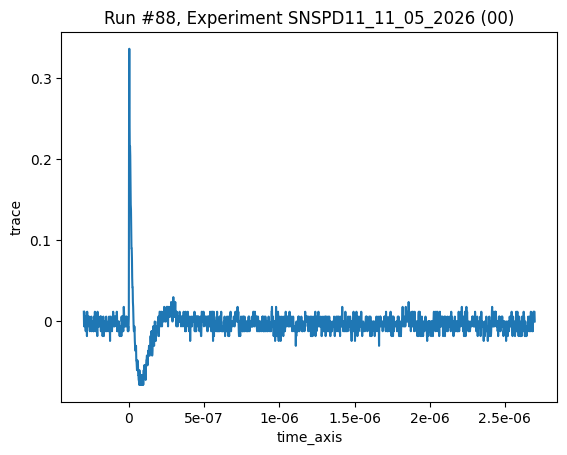

In [176]:
plot_by_id(88)

In [180]:
print(p_att.ask(f'VOLT?'))

5.5


In [181]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

currents = params.device_line_1['currents'][-13:-5] # -12uA to -13.75uA

for curr in currents:
    params.MSO5_set_standard_counts(MS)
    p_att.write(f'VOLT {v_att_range[-1]}')
    
    # Wait 2min for device to return to normal state 
    time.sleep(60)

    yoko.current(curr)
    print(f'Starting current {curr}')
    
    params.MSO5_counts_vs_attenuation(MS, dmm, yoko, p_att, device=params.device_line_1, v_att_range=v_att_range, n_captures=10, interval=1, current=curr, station=station)
    
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

    time.sleep(60)

Laser enable status: True
Starting current -1.2e-05
Set standard oscilloscope parameters for counts


2026-05-13 23:15:39,386 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-05-13 23:15:39,389 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



update station
Starting experimental run with id: 89. 
89
Current is -1.2e-05
Starting V=5.5
This acquisition will take 10s
23 16
Starting V=5.45
This acquisition will take 10s
23 16
Starting V=5.4
This acquisition will take 10s
23 16
Starting V=5.35
This acquisition will take 10s
23 16
Starting V=5.3
This acquisition will take 10s
23 17
Starting V=5.25
This acquisition will take 10s
23 17
Starting V=5.2
This acquisition will take 10s
23 17
Starting V=5.15
This acquisition will take 10s
23 18
Starting V=5.1
This acquisition will take 10s
23 18
Starting V=5.05
This acquisition will take 10s
23 18
Starting V=5
This acquisition will take 10s
23 18
Starting V=4.95
This acquisition will take 10s
23 19
Starting V=4.9
This acquisition will take 10s
23 19
Starting V=4.85
This acquisition will take 10s
23 19
Starting V=4.8
This acquisition will take 10s
23 19
Starting V=4.75
This acquisition will take 10s
23 20
Starting V=4.7
This acquisition will take 10s
23 20
Starting V=4.65
This acquisition

2026-05-13 23:28:36,981 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-05-13 23:28:36,983 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



update station
Starting experimental run with id: 90. 
90
Current is -1.225e-05
Starting V=5.5
This acquisition will take 10s
23 29
Starting V=5.45
This acquisition will take 10s
23 29
Starting V=5.4
This acquisition will take 10s
23 29
Starting V=5.35
This acquisition will take 10s
23 29
Starting V=5.3
This acquisition will take 10s
23 30
Starting V=5.25
This acquisition will take 10s
23 30
Starting V=5.2
This acquisition will take 10s
23 30
Starting V=5.15
This acquisition will take 10s
23 30
Starting V=5.1
This acquisition will take 10s
23 31
Starting V=5.05
This acquisition will take 10s
23 31
Starting V=5
This acquisition will take 10s
23 31
Starting V=4.95
This acquisition will take 10s
23 31
Starting V=4.9
This acquisition will take 10s
23 32
Starting V=4.85
This acquisition will take 10s
23 32
Starting V=4.8
This acquisition will take 10s
23 32
Starting V=4.75
This acquisition will take 10s
23 33
Starting V=4.7
This acquisition will take 10s
23 33
Starting V=4.65
This acquisiti

...

update station
Starting experimental run with id: 94. 
94
Current is -1.325e-05
Starting V=5.5
This acquisition will take 10s
0 20
Starting V=5.45
This acquisition will take 10s
0 20
Starting V=5.4
This acquisition will take 10s
0 21
Starting V=5.35
This acquisition will take 10s
0 21
Starting V=5.3
This acquisition will take 10s
0 21
Starting V=5.25
This acquisition will take 10s
0 22
Starting V=5.2
This acquisition will take 10s
0 22
Starting V=5.15
This acquisition will take 10s
0 22
Starting V=5.1
This acquisition will take 10s
0 22
Starting V=5.05
This acquisition will take 10s
0 23
Starting V=5
This acquisition will take 10s
0 23
Starting V=4.95
This acquisition will take 10s
0 23
Starting V=4.9
This acquisition will take 10s
0 23
Starting V=4.85
This acquisition will take 10s
0 24
Starting V=4.8
This acquisition will take 10s
0 24
Starting V=4.75
This acquisition will take 10s
0 24
Starting V=4.7
This acquisition will take 10s
0 25
Starting V=4.65
This acquisition will take 10s


2026-05-14 00:33:12,687 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-05-14 00:33:12,690 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



update station
Starting experimental run with id: 95. 
95
Current is -1.35e-05
Starting V=5.5
This acquisition will take 10s
0 33
Starting V=5.45
This acquisition will take 10s
0 33
Starting V=5.4
This acquisition will take 10s
0 34
Starting V=5.35
This acquisition will take 10s
0 34
Starting V=5.3
This acquisition will take 10s
0 34
Starting V=5.25
This acquisition will take 10s
0 35
Starting V=5.2
This acquisition will take 10s
0 35
Starting V=5.15
This acquisition will take 10s
0 35
Starting V=5.1
This acquisition will take 10s
0 35
Starting V=5.05
This acquisition will take 10s
0 36
Starting V=5
This acquisition will take 10s
0 36
Starting V=4.95
This acquisition will take 10s
0 36
Starting V=4.9
This acquisition will take 10s
0 36
Starting V=4.85
This acquisition will take 10s
0 37
Starting V=4.8
This acquisition will take 10s
0 37
Starting V=4.75
This acquisition will take 10s
0 37
Starting V=4.7
This acquisition will take 10s
0 37
Starting V=4.65
This acquisition will take 10s
0

2026-05-14 00:46:10,557 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-05-14 00:46:10,560 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



update station
Starting experimental run with id: 96. 
96
Current is -1.375e-05
Starting V=5.5
This acquisition will take 10s
0 46
Starting V=5.45
This acquisition will take 10s
0 46
Starting V=5.4
This acquisition will take 10s
0 47
Starting V=5.35
This acquisition will take 10s
0 47
Starting V=5.3
This acquisition will take 10s
0 47
Starting V=5.25
This acquisition will take 10s
0 47
Starting V=5.2
This acquisition will take 10s
0 48
Starting V=5.15
This acquisition will take 10s
0 48
Starting V=5.1
This acquisition will take 10s
0 48
Starting V=5.05
This acquisition will take 10s
0 48
Starting V=5
This acquisition will take 10s
0 49
Starting V=4.95
This acquisition will take 10s
0 49
Starting V=4.9
This acquisition will take 10s
0 49
Starting V=4.85
This acquisition will take 10s
0 50
Starting V=4.8
This acquisition will take 10s
0 50
Starting V=4.75
This acquisition will take 10s
0 50
Starting V=4.7
This acquisition will take 10s
0 50
Starting V=4.65
This acquisition will take 10s


Re-running because latched after first one - didn't ramp current down between runs.  

In [193]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.capture_trace(MS, dmm, yoko, p_att)

time.sleep(10)
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
Oscilloscope set for trace capture
Starting experimental run with id: 97. 
97
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Laser enable status: False


In [21]:
laser.enable()

False

In [26]:
v_att = params.att_blue_v_attenuator_range
np.arange(v_att['start'], v_att['stop'], v_att['step'])

array([3.4 , 3.45, 3.5 , 3.55, 3.6 , 3.65, 3.7 , 3.75, 3.8 , 3.85, 3.9 ,
       3.95, 4.  , 4.05, 4.1 , 4.15, 4.2 , 4.25, 4.3 , 4.35, 4.4 , 4.45,
       4.5 , 4.55, 4.6 , 4.65, 4.7 , 4.75, 4.8 , 4.85, 4.9 , 4.95, 5.  ,
       5.05, 5.1 , 5.15, 5.2 , 5.25, 5.3 , 5.35, 5.4 , 5.45, 5.5 ])

In [28]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

currents = params.device_line_1['currents'][-13:-5] # -12uA to -13.75uA

v_att = params.att_blue_v_attenuator_range
v_att_range = np.arange(v_att['start'], v_att['stop'], v_att['step'])

for curr in currents:
    params.MSO5_set_standard_counts(MS)

    # Set voltage to beginning of range 
    p_att.write(f'VOLT {v_att_range[-1]}')

    params.ramp_yoko_current(yoko, curr, 0.5e-6)

    
    params.MSO5_counts_vs_attenuation(MS, dmm, yoko, p_att, device=params.device_line_1, v_att_range=v_att_range, n_captures=10, interval=1, current=curr, station=station)

    # Ramp current down to correct for latching 
    params.ramp_yoko_current(yoko, 0, 0.5e-6)

    # Wait 2min for device to return to normal state 
    time.sleep(60)  
    
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')


Laser enable status: True
Ramping to -1.2e-05
Set standard oscilloscope parameters for counts


2026-05-14 12:53:39,194 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-05-14 12:53:39,197 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



update station
Starting experimental run with id: 100. 
100
Current is -1.2e-05
Starting V=5.5
This acquisition will take 10s
12 54
Starting V=5.45
This acquisition will take 10s
12 54
Starting V=5.4
This acquisition will take 10s
12 54
Starting V=5.35
This acquisition will take 10s
12 54
Starting V=5.3
This acquisition will take 10s
12 55
Starting V=5.25
This acquisition will take 10s
12 55
Starting V=5.2
This acquisition will take 10s
12 55
Starting V=5.15
This acquisition will take 10s
12 56
Starting V=5.1
This acquisition will take 10s
12 56
Starting V=5.05
This acquisition will take 10s
12 56
Starting V=5
This acquisition will take 10s
12 56
Starting V=4.95
This acquisition will take 10s
12 57
Starting V=4.9
This acquisition will take 10s
12 57
Starting V=4.85
This acquisition will take 10s
12 57
Starting V=4.8
This acquisition will take 10s
12 57
Starting V=4.75
This acquisition will take 10s
12 58
Starting V=4.7
This acquisition will take 10s
12 58
Starting V=4.65
This acquisiti

2026-05-14 13:07:33,981 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-05-14 13:07:33,984 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



update station
Starting experimental run with id: 101. 
101
Current is -1.225e-05
Starting V=5.5
This acquisition will take 10s
13 8
Starting V=5.45
This acquisition will take 10s
13 8
Starting V=5.4
This acquisition will take 10s
13 8
Starting V=5.35
This acquisition will take 10s
13 8
Starting V=5.3
This acquisition will take 10s
13 9
Starting V=5.25
This acquisition will take 10s
13 9
Starting V=5.2
This acquisition will take 10s
13 9
Starting V=5.15
This acquisition will take 10s
13 9
Starting V=5.1
This acquisition will take 10s
13 10
Starting V=5.05
This acquisition will take 10s
13 10
Starting V=5
This acquisition will take 10s
13 10
Starting V=4.95
This acquisition will take 10s
13 11
Starting V=4.9
This acquisition will take 10s
13 11
Starting V=4.85
This acquisition will take 10s
13 11
Starting V=4.8
This acquisition will take 10s
13 11
Starting V=4.75
This acquisition will take 10s
13 12
Starting V=4.7
This acquisition will take 10s
13 12
Starting V=4.65
This acquisition wil

...

update station
Starting experimental run with id: 105. 
105
Current is -1.325e-05
Starting V=5.5
This acquisition will take 10s
14 3
Starting V=5.45
This acquisition will take 10s
14 4
Starting V=5.4
This acquisition will take 10s
14 4
Starting V=5.35
This acquisition will take 10s
14 4
Starting V=5.3
This acquisition will take 10s
14 4
Starting V=5.25
This acquisition will take 10s
14 5
Starting V=5.2
This acquisition will take 10s
14 5
Starting V=5.15
This acquisition will take 10s
14 5
Starting V=5.1
This acquisition will take 10s
14 5
Starting V=5.05
This acquisition will take 10s
14 6
Starting V=5
This acquisition will take 10s
14 6
Starting V=4.95
This acquisition will take 10s
14 6
Starting V=4.9
This acquisition will take 10s
14 7
Starting V=4.85
This acquisition will take 10s
14 7
Starting V=4.8
This acquisition will take 10s
14 7
Starting V=4.75
This acquisition will take 10s
14 7
Starting V=4.7
This acquisition will take 10s
14 8
Starting V=4.65
This acquisition will take 10

2026-05-14 14:17:13,313 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-05-14 14:17:13,315 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



update station
Starting experimental run with id: 106. 
106
Current is -1.35e-05
Starting V=5.5
This acquisition will take 10s
14 17
Starting V=5.45
This acquisition will take 10s
14 18
Starting V=5.4
This acquisition will take 10s
14 18
Starting V=5.35
This acquisition will take 10s
14 18
Starting V=5.3
This acquisition will take 10s
14 18
Starting V=5.25
This acquisition will take 10s
14 19
Starting V=5.2
This acquisition will take 10s
14 19
Starting V=5.15
This acquisition will take 10s
14 19
Starting V=5.1
This acquisition will take 10s
14 19
Starting V=5.05
This acquisition will take 10s
14 20
Starting V=5
This acquisition will take 10s
14 20
Starting V=4.95
This acquisition will take 10s
14 20
Starting V=4.9
This acquisition will take 10s
14 20
Starting V=4.85
This acquisition will take 10s
14 21
Starting V=4.8
This acquisition will take 10s
14 21
Starting V=4.75
This acquisition will take 10s
14 21
Starting V=4.7
This acquisition will take 10s
14 22
Starting V=4.65
This acquisit

2026-05-14 14:31:12,331 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-05-14 14:31:12,334 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



update station
Starting experimental run with id: 107. 
107
Current is -1.375e-05
Starting V=5.5
This acquisition will take 10s
14 31
Starting V=5.45
This acquisition will take 10s
14 31
Starting V=5.4
This acquisition will take 10s
14 32
Starting V=5.35
This acquisition will take 10s
14 32
Starting V=5.3
This acquisition will take 10s
14 32
Starting V=5.25
This acquisition will take 10s
14 33
Starting V=5.2
This acquisition will take 10s
14 33
Starting V=5.15
This acquisition will take 10s
14 33
Starting V=5.1
This acquisition will take 10s
14 33
Starting V=5.05
This acquisition will take 10s
14 34
Starting V=5
This acquisition will take 10s
14 34
Starting V=4.95
This acquisition will take 10s
14 34
Starting V=4.9
This acquisition will take 10s
14 34
Starting V=4.85
This acquisition will take 10s
14 35
Starting V=4.8
This acquisition will take 10s
14 35
Starting V=4.75
This acquisition will take 10s
14 35
Starting V=4.7
This acquisition will take 10s
14 35
Starting V=4.65
This acquisi

In [35]:
idx, _ = params.match(-14e-6, params.device_line_1['currents'])

Check match:-1.4e-05 (test) = [-1.4e-05]?


In [46]:
idx[0][0]

np.int64(56)

In [48]:
np.diff(params.device_line_1['currents'][int(idx[0][0]):-1])

array([-2.5e-07, -2.5e-07, -2.5e-07])

In [ ]:
# Run higher than -14uA and to greater attenuation to see if the efficiency improves more  

In [50]:
currents = np.arange(-14e-6, params.device_line_1['currents'][-1], -1e-7)

In [54]:
laser.enable()

False

In [55]:
params.ramp_yoko_current(yoko, -12e-6, 0.5e-6)

Ramping to -1.2e-05


In [72]:
target=-3e-6
step = 0.5e-6
print(f'Ramping to {target}')
start = yoko.current()
print(start)
step = step if target > start else -step
currents = np.arange(start, target+(step-start), step)
for curr in currents: 
    print(curr)
    time.sleep(1)

Ramping to -3e-06
-3.25e-06
-3.25e-06
-2.75e-06
-2.25e-06
-1.7500000000000002e-06
-1.2500000000000003e-06
-7.500000000000004e-07
-2.5000000000000057e-07
2.499999999999993e-07


In [64]:
yoko.current()

-2.5e-07

In [65]:
target+step

-5e-07

In [58]:
params.capture_trace(MS, dmm, yoko, p_att)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 109. 
109
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;730.00E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


In [73]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

currents = np.arange(-14e-6, params.device_line_1['currents'][-1], -1e-7)

v_att = params.att_blue_v_attenuator_range
v_att_range = np.arange(v_att['start'], 6, v_att['step'])

for curr in currents:
    params.MSO5_set_standard_counts(MS)

    # Set voltage to beginning of range 
    p_att.write(f'VOLT {v_att_range[-1]}')

    params.ramp_yoko_current(yoko, curr, 0.5e-6) # <- this is not working, but attenuation function sets it 

    params.MSO5_counts_vs_attenuation(MS, dmm, yoko, p_att, device=params.device_line_1, v_att_range=v_att_range, n_captures=10, interval=1, current=curr, station=station)

    # Ramp current down to correct for latching 
    params.ramp_yoko_current(yoko, 0, 0.5e-6)

    # Wait 2min for device to return to normal state 
    time.sleep(60)  
    
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')


Laser enable status: True
Ramping to -1.4e-05
Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 110. 
110
Current is -1.4e-05
Starting V=5.95
This acquisition will take 10s
15 1
Starting V=5.9
This acquisition will take 10s
15 1
Starting V=5.85
This acquisition will take 10s
15 2
Starting V=5.8
This acquisition will take 10s
15 2
Starting V=5.75
This acquisition will take 10s
15 2
Starting V=5.7
This acquisition will take 10s
15 2
Starting V=5.65
This acquisition will take 10s
15 3
Starting V=5.6
This acquisition will take 10s
15 3
Starting V=5.55
This acquisition will take 10s
15 3
Starting V=5.5
This acquisition will take 10s
15 4
Starting V=5.45
This acquisition will take 10s
15 4
Starting V=5.4
This acquisition will take 10s
15 4
Starting V=5.35
This acquisition will take 10s
15 4
Starting V=5.3
This acquisition will take 10s
15 5
Starting V=5.25
This acquisition will take 10s
15 5
Starting V=5.2
This acquisition will take 10s
15 5
St

# Wavelength Sweep 

In [74]:
laser.enable()

False

In [76]:
yoko.current()

5e-07

In [77]:
pms120.power()

2026-05-16 17:56:27,215 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



1.83831422e-10

Best efficiency result achieved for 14uA and 5.5V applied to attenuator (ID 87)

In [104]:
p_att.write('VOLT 5.5')
p_att.ask('VOLT?')
params.ramp_yoko_current(yoko, -14e-6, 0.5e-6)

Ramping to -1.4e-05


In [105]:
yoko.current()

-1.45e-05

In [106]:
p_att.write('VOLT 5.5')
print(f'Attenuator voltage: {p_att.ask('VOLT?')}')
yoko.current(-14e-6)
print(f'Current: {yoko.current()}')

l = [float(val) for val in params.laser_wav_range.values()]
laser_wav_range = np.arange(l[0], l[1]+l[2], l[2])
params.counts_vs_wavelength(MS, dmm, yoko, p_att, laser, pmeter90=pms120,
                            device=params.device_line_1, n_captures=10, interval=1, wavelength_range=laser_wav_range, station=station)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Attenuator voltage: 5.5
Current: -1.4e-05
Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 124. 
124
Laser enable status: False
1.528e-06
Power: 7.0
Frequency coarse: 196.1992THz


2026-05-16 18:16:55,585 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Wavelength (calculated) is 1528.0004097876035nm
Powermeter wavelength is 1.528e-06
Laser enable status: True
This acquisition will take 10s
18 17


2026-05-16 18:17:20,930 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
1.529e-06
Power: 7.0
Frequency coarse: 196.0709THz
Wavelength (calculated) is 1529.0002647001672nm
Powermeter wavelength is 1.529e-06
Laser enable status: True
This acquisition will take 10s
18 17


...

Laser enable status: False
1.5640000000000027e-06
Power: 7.0
Frequency coarse: 191.6831THz
Wavelength (calculated) is 1564.0004674381833nm
Powermeter wavelength is 1.564e-06
Laser enable status: True
This acquisition will take 10s
18 32


2026-05-16 18:32:33,473 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
1.5650000000000028e-06
Power: 7.0
Frequency coarse: 191.5606THz
Wavelength (calculated) is 1565.0006212133394nm
Powermeter wavelength is 1.565e-06
Laser enable status: True
This acquisition will take 10s
18 32


2026-05-16 18:32:58,835 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
1.5660000000000029e-06
Power: 7.0
Frequency coarse: 191.4383THz
Wavelength (calculated) is 1566.0004189339331nm
Powermeter wavelength is 1.566e-06
Laser enable status: True
This acquisition will take 10s
18 33
Laser enable status: False


In [107]:
laser.enable()

False

In [109]:
MS.ask(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold?')
# MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

'342.0000E-3'

In [110]:
yoko.current()

-1.4e-05

In [111]:
print(params.device_line_1['thresholds'])

{'range1': {'current': '-13e-6', 'threshold1': '342e-3', 'threshold2': '120e-3'}, 'range2': {'current': '-8e-6', 'threshold1': '198e-3', 'threshold2': '60e-3'}, 'range3': {'current': 0, 'threshold1': '78e-3', 'threshold2': '48e-3'}}


In [115]:
params.capture_trace(MS, dmm, yoko, p_att)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 125. 
125
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;575.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


plot_by_id(125)

([<Axes: title={'center': 'Run #125, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

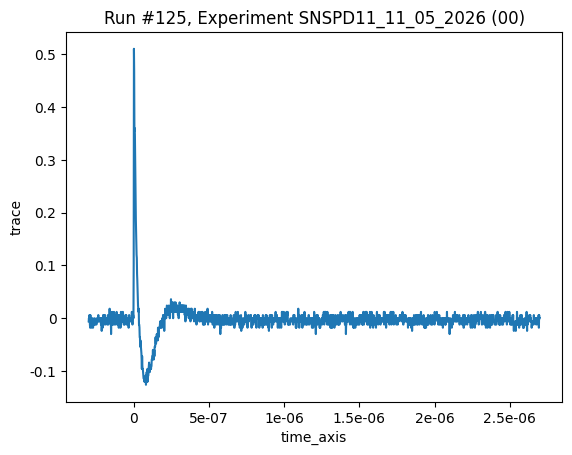

In [116]:
plot_by_id(125)

Try current sweep again to check numbers and function 

In [119]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)
params.MSO5_set_standard_counts(MS)
# Choose 5.5v
p_att.write(f'VOLT {params.device_line_1['v_attenuator_vals']['att_blue_v_2']}')
# yoko.current(0)
# Check shielding: box and fridge entry 

2026-05-16 19:51:44,204 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06


In [122]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.MSO5_counts_vs_current(device=params.device_line_1, n_captures=10, interval=1, osc=MS, 
                              dmm=dmm, yoko=yoko) 

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 126. 
126
This acquisition will take 10s
19 55
This acquisition will take 10s
19 55
This acquisition will take 10s
19 55
This acquisition will take 10s
19 56
This acquisition will take 10s
19 56
This acquisition will take 10s
19 56
This acquisition will take 10s
19 56
This acquisition will take 10s
19 57
This acquisition will take 10s
19 57
This acquisition will take 10s
19 57
This acquisition will take 10s
19 57
This acquisition will take 10s
19 58
This acquisition will take 10s
19 58
This acquisition will take 10s
19 58
This acquisition will take 10s
19 58
This acquisition will take 10s
19 59
This acquisition will take 10s
19 59
This acquisition will take 10s
19 59
This acquisition will take 10s
19 59
This acquisition will take 10s
20 0
This acquisition will take 10s
20 0
This acquisition will take 10s
20 0
This acquisition will take 10s
20 0
This acquisition wi

([<Axes: title={'center': 'Run #126, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='Current ($10^{-6}$ I)', ylabel='cps'>,
  <Axes: title={'center': 'Run #126, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='Current ($10^{-6}$ I)', ylabel='cps'>],
 [None, None])

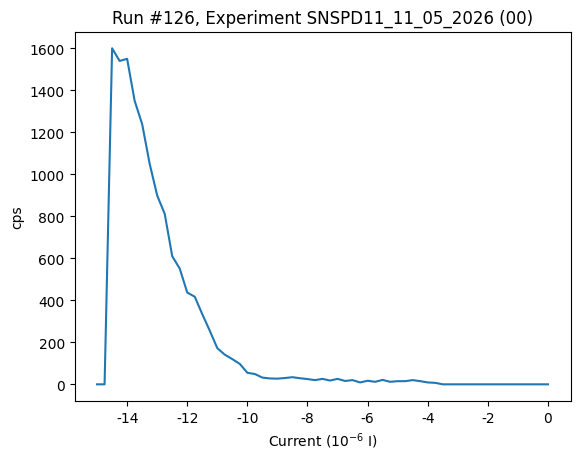

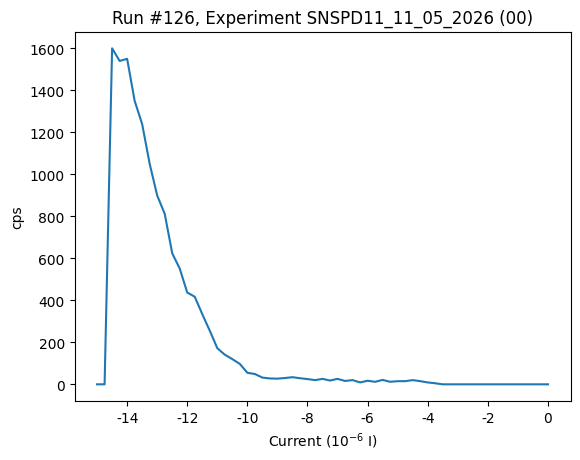

In [123]:
plot_by_id(126)

In [124]:
params.laser_get_standard(laser)

Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm


In [125]:
laser.frequency_coarse()

193414400000000.0

In [127]:
data = load_by_id(125).get_parameter_data()
data.keys()

dict_keys(['dmm_volt', 'h_position_perc', 'h_samplerate', 'h_samples', 'trace', 'v_attenuator', 'yoko_current'])

* Recalculate photon number across wavelength range
* But what is with the current sweep 

In [128]:
laser.power()

7.0

# Attempting wavelength sweep again while watching 

In [129]:
p_att.write('VOLT 5.5')
print(f'Attenuator voltage: {p_att.ask('VOLT?')}')
yoko.current(-14e-6)
print(f'Current: {yoko.current()}')

l = [float(val) for val in params.laser_wav_range.values()]
laser_wav_range = np.arange(l[0], l[1]+l[2], l[2])
params.counts_vs_wavelength(MS, dmm, yoko, p_att, laser, pmeter90=pms120,
                            device=params.device_line_1, n_captures=10, interval=1, wavelength_range=laser_wav_range, station=station)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Attenuator voltage: 5.5
Current: -1.4e-05
Set standard oscilloscope parameters for counts
update station


2026-05-18 11:11:43,962 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Starting experimental run with id: 138. 
138
Laser enable status: False
1.528e-06
Power: 7.0
Frequency coarse: 196.1992THz
Wavelength (calculated) is 1528.0004097876035nm
Powermeter wavelength is 1.528e-06
Laser enable status: True
This acquisition will take 10s
11 11


2026-05-18 11:12:09,306 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
1.529e-06
Power: 7.0
Frequency coarse: 196.0709THz
Wavelength (calculated) is 1529.0002647001672nm
Powermeter wavelength is 1.529e-06
Laser enable status: True
This acquisition will take 10s
11 12


2026-05-18 11:12:34,651 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
1.5300000000000002e-06
Power: 7.0
Frequency coarse: 195.9427THz
Wavelength (calculated) is 1530.000648148668nm
Powermeter wavelength is 1.53e-06
Laser enable status: True
This acquisition will take 10s
11 12


2026-05-18 11:12:50,690 ¦ qcodes.dataset.measurements ¦ WARNING ¦ measurements ¦ __exit__ ¦ 758 ¦ An exception occurred in measurement with guid: c4092867-0000-0000-0000-019e38a38d07;
Traceback:
Traceback (most recent call last):
  File "D:\SNSPD\SNSPD2\snspd.py", line 768, in counts_vs_wavelength
    counts2= []
        ^^^^^^^
KeyboardInterrupt



KeyboardInterrupt: 

Observed thousands of counts per time trace already. Trying current sweep now. 

In [132]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)
params.MSO5_set_standard_counts(MS)
# Choose 5.5v
p_att.write(f'VOLT {params.device_line_1['v_attenuator_vals']['att_blue_v_2']}')
# yoko.current(0)
# Check shielding: box and fridge entry 

2026-05-18 11:15:27,730 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06


In [135]:
print('Set standard oscilloscope parameters for counts')
params.MSO5_set_standard_counts(MS)
time.sleep(2)

Set standard oscilloscope parameters for counts


In [136]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.MSO5_counts_vs_current(device=params.device_line_1, n_captures=10, interval=1, osc=MS, currents=[-14e-6],
                              dmm=dmm, yoko=yoko) 

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 140. 
140
This acquisition will take 10s
11 17
Laser enable status: False


In [140]:
ID = 138 
data = load_by_id(ID).get_parameter_data()
data['CR1']['CR1']

array([20461., 17127.,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan])

In [142]:
ID = 140
data = load_by_id(ID).get_parameter_data()
data['CR1']['CR1']

array([1857.])

In [144]:
p_att.write('VOLT 5.5')
print(f'Attenuator voltage: {p_att.ask('VOLT?')}')
yoko.current(-14e-6)
print(f'Current: {yoko.current()}')

l = [float(val) for val in params.laser_wav_range.values()]
laser_wav_range = np.arange(l[0], l[1]+l[2], l[2])
wav = laser_wav_range[0]

params.laser_set_standard(laser, wavelength=wav, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pms120, wavelength=wav)

2026-05-18 11:23:18,540 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Attenuator voltage: 5.5
Current: -1.4e-05
Power: 7.0
Frequency coarse: 196.1992THz
Wavelength (calculated) is 1528.0004097876035nm
Powermeter wavelength is 1.528e-06


In [145]:
# ############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

Laser enable status: True


In [146]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')


Laser enable status: False


In [148]:
wav=1550e-9
params.laser_set_standard(laser, wavelength=wav, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pms120, wavelength=wav)

2026-05-18 11:25:27,920 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06


In [149]:
# ############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

Laser enable status: True


In [150]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')


Laser enable status: False


Try with voltage turned down on attenuator - maybe it is not attenuating well outside its normal operational range

In [151]:
p_att.write('VOLT 5')
time.sleep(20)
print(f'Attenuator voltage: {p_att.ask('VOLT?')}')
yoko.current(-14e-6)
print(f'Current: {yoko.current()}')

l = [float(val) for val in params.laser_wav_range.values()]
laser_wav_range = np.arange(l[0], l[1]+l[2], l[2])
params.counts_vs_wavelength(MS, dmm, yoko, p_att, laser, pmeter90=pms120,
                            device=params.device_line_1, n_captures=10, interval=1, wavelength_range=laser_wav_range, station=station)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Attenuator voltage: 5
Current: -1.4e-05
Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 141. 
141
Laser enable status: False
1.528e-06
Power: 7.0
Frequency coarse: 196.1992THz


2026-05-18 11:38:46,534 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Wavelength (calculated) is 1528.0004097876035nm
Powermeter wavelength is 1.528e-06
Laser enable status: True
This acquisition will take 10s
11 39


2026-05-18 11:39:11,878 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
1.529e-06
Power: 7.0
Frequency coarse: 196.0709THz
Wavelength (calculated) is 1529.0002647001672nm
Powermeter wavelength is 1.529e-06
Laser enable status: True
This acquisition will take 10s
11 39


...

Laser enable status: False
1.5640000000000027e-06
Power: 7.0
Frequency coarse: 191.6831THz
Wavelength (calculated) is 1564.0004674381833nm
Powermeter wavelength is 1.564e-06
Laser enable status: True
This acquisition will take 10s
11 54


2026-05-18 11:54:24,500 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
1.5650000000000028e-06
Power: 7.0
Frequency coarse: 191.5606THz
Wavelength (calculated) is 1565.0006212133394nm
Powermeter wavelength is 1.565e-06
Laser enable status: True
This acquisition will take 10s
11 54


2026-05-18 11:54:49,845 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
1.5660000000000029e-06
Power: 7.0
Frequency coarse: 191.4383THz
Wavelength (calculated) is 1566.0004189339331nm
Powermeter wavelength is 1.566e-06
Laser enable status: True
This acquisition will take 10s
11 55
Laser enable status: False


Repeat sweep with attenuation 

In [7]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)
params.MSO5_set_standard_counts(MS)
p_att.write(f'VOLT {v_att_range[-1]}')
yoko.current(-14e-6)
# Check shielding: box and fridge entry 

v = params.att_blue_v_attenuator_range
v_att_range = np.arange(v['start'], v['stop'], v['step'])

############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.MSO5_counts_vs_attenuation(MS, dmm, yoko, p_att, device=params.device_line_1, v_att_range=v_att_range, n_captures=10, interval=1, current=-14e-6, station=station)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

2026-05-18 13:22:46,268 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Laser enable status: False
Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06
Laser enable status: True
Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 143. 
143
Current is -1.4e-05
Starting V=5.5
This acquisition will take 10s
13 23
Starting V=5.45
This acquisition will take 10s
13 23
Starting V=5.4
This acquisition will take 10s
13 23
Starting V=5.35
This acquisition will take 10s
13 23
Starting V=5.3
This acquisition will take 10s
13 24
Starting V=5.25
This acquisition will take 10s
13 24
Starting V=5.2
This acquisition will take 10s
13 24
Starting V=5.15
This acquisition will take 10s
13 25
Starting V=5.1
This acquisition will take 10s
13 25
Starting V=5.05
This acquisition will take 10s
13 25
Starting V=5
This acquisition will take 10s
13 25
Starting V=4.95
This acquisition will take 10s
13 26
Starting V=4.9
This acquisition wil